# Clustering the Polar Bears


In [1]:
# !pip install haversine
# !pip install rioxarray

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
from haversine import haversine, Unit
from ipyleaflet import Map, Marker, MarkerCluster, basemaps, basemap_to_tiles
from ipywidgets import HTML
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from warnings import filterwarnings

filterwarnings('ignore')

## Load data

In [7]:
# Load the data into a pandas dataframe
df = pd.read_parquet("../data/processed/feature_dataset.parquet")
df.head()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,season,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real,movement_pattern
0,1,1986-07-01 18:00:00,69.7730,-141.3960,5835,5835,69.772693,-141.403451,NaN,NaN,...,verano,-2.199487e+06,246846.113968,NaN,NaN,NaN,NaN,0.000000,1.560623,estacionario
1,1,1986-07-02 00:00:00,69.7738,-141.3834,2517,2517,69.773429,-141.388987,69.772693,-141.403451,...,verano,-2.199467e+06,246281.720783,5835.0,5835.0,204.452866,NaN,0.000000,7.640792,estacionario
2,1,1986-07-02 06:00:00,69.7736,-141.3448,5323,5323,69.764930,-141.331186,69.773429,-141.388987,...,verano,-2.200658e+06,244167.346190,2517.0,2517.0,203.378720,204.452866,1.074146,7.640792,estacionario
3,1,1986-07-02 12:00:00,69.7727,-141.2902,8840,8840,69.783728,-141.265125,69.764930,-141.331186,...,verano,-2.198852e+06,241400.844917,5323.0,5323.0,186.624033,203.378720,16.754687,7.640792,estacionario
4,1,1986-07-02 18:00:00,69.7717,-141.2289,11637,11637,69.778055,-141.296034,69.783728,-141.265125,...,verano,-2.199351e+06,242656.504996,8840.0,8840.0,186.441201,186.624033,0.182832,7.640792,estacionario


In [13]:
df[df.UniqueAnimalID == 311]

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,season,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real,movement_pattern
176398,311,2013-07-01 18:00:00,70.4714,-136.2293,30,30,70.471453,-136.229339,NaN,NaN,...,verano,-2.134876e+06,45812.952411,NaN,NaN,NaN,NaN,0.000000,6.426721,estacionario
176399,311,2013-07-02 00:00:00,70.4720,-136.4244,30,30,70.471996,-136.424426,70.471453,-136.229339,...,verano,-2.134648e+06,53080.250032,30.0,30.0,187.270666,NaN,0.000000,28.040156,activo
176400,311,2013-07-02 06:00:00,70.4354,-136.4507,30,30,70.435372,-136.450795,70.471996,-136.424426,...,verano,-2.138702e+06,54165.984200,30.0,30.0,207.411237,187.270666,20.140571,28.040156,activo
176401,311,2013-07-02 12:00:00,70.4624,-136.5439,30,30,70.462355,-136.543980,70.435372,-136.450795,...,verano,-2.135606e+06,57563.245937,30.0,30.0,204.849140,207.411237,2.562097,28.040156,activo
176402,311,2013-07-02 18:00:00,70.5411,-136.7615,30,30,70.541139,-136.761338,70.462355,-136.543980,...,verano,-2.126600e+06,65394.728115,30.0,30.0,174.752385,204.849140,30.096755,28.040156,activo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177002,311,2013-11-29 18:00:00,70.9056,-152.4745,30,30,70.905555,-152.474376,70.907001,-152.484029,...,invierno,-1.990721e+06,626693.397116,30.0,30.0,177.327101,153.447355,23.879746,0.751805,estacionario
177003,311,2013-11-30 00:00:00,70.9069,-152.4838,30,30,70.906878,-152.483738,70.905555,-152.474376,...,invierno,-1.990479e+06,626974.450270,30.0,30.0,180.184930,177.327101,2.857829,5.603059,estacionario
177004,311,2013-11-30 06:00:00,70.9030,-152.4552,30,30,70.903027,-152.455187,70.906878,-152.483738,...,invierno,-1.991200e+06,626111.058489,30.0,30.0,177.999352,180.184930,2.185578,5.603059,estacionario
177005,311,2013-11-30 12:00:00,70.8915,-152.3489,30,30,70.891514,-152.348925,70.903027,-152.455187,...,invierno,-1.993580e+06,622799.047197,30.0,30.0,172.563381,177.999352,5.435970,5.603059,estacionario


In [14]:
df.shape

(294215, 38)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294215 entries, 0 to 294214
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   UniqueAnimalID         294215 non-null  int64         
 1   timestamp              294215 non-null  datetime64[ns]
 2   mu_lat                 294215 non-null  float64       
 3   mu_lon                 294215 non-null  float64       
 4   se_mu_x                294215 non-null  int64         
 5   se_mu_y                294215 non-null  int64         
 6   adj_lat                294215 non-null  float64       
 7   adj_lon                294215 non-null  float64       
 8   prev_lat               293822 non-null  float64       
 9   prev_lon               293822 non-null  float64       
 10  prev_time              294215 non-null  datetime64[ns]
 11  distance_km            294215 non-null  float64       
 12  time_diff_hr           294215 non-null  floa

In [16]:
df.describe()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,AvgLongitude,Year,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real
count,294215.000000,294215,294215.000000,294215.000000,294215.000000,294215.000000,294215.000000,294215.000000,293822.000000,293822.000000,...,294215.000000,294215.000000,2.942150e+05,2.942150e+05,293822.000000,293822.000000,293822.000000,293430.000000,294215.000000,294215.000000
mean,252.595775,2001-02-27 04:01:01.644715648,72.299086,-154.581870,10321.019826,10321.019826,72.299071,-154.581750,72.300323,-154.572981,...,-154.580750,1999.506235,-1.767268e+06,6.286931e+05,10324.541260,10324.541260,180.025500,180.025224,22.317130,21.775596
min,1.000000,1985-07-01 18:00:00,65.071000,-179.999900,11.000000,11.000000,65.073795,-180.185209,65.073795,-180.185209,...,-179.969657,1985.000000,-2.320601e+06,-5.805984e+05,11.000000,11.000000,96.671665,96.671665,0.000000,0.011927
25%,108.000000,1992-07-23 00:00:00,70.847200,-166.173500,2752.000000,2752.000000,70.846895,-166.173693,70.848102,-166.150305,...,-166.017760,1991.000000,-1.995308e+06,3.221916e+05,2755.250000,2755.250000,166.599502,166.599932,8.898862,12.687108
50%,279.000000,2002-08-31 12:00:00,71.880400,-152.410900,8651.000000,8651.000000,71.879940,-152.410637,71.881608,-152.401962,...,-151.297349,2000.000000,-1.791045e+06,5.641188e+05,8656.000000,8656.000000,179.974871,179.972993,18.919725,19.211106
75%,361.000000,2008-11-06 18:00:00,73.444200,-144.126050,15501.500000,15501.500000,73.443720,-144.126218,73.444619,-144.123211,...,-144.960464,2008.000000,-1.556768e+06,9.394948e+05,15506.000000,15506.000000,193.451575,193.450976,32.219748,27.650653
max,541.000000,2017-11-30 18:00:00,79.999700,-111.104300,66766.000000,66766.000000,80.012180,-111.104288,80.012180,-111.104288,...,-124.503721,2017.000000,-7.767790e+05,1.645228e+06,66766.000000,66766.000000,263.884632,263.884632,128.119234,382.404926
std,151.705725,NaN,2.083701,14.039252,8853.029487,8853.029487,2.083780,14.039521,2.083033,14.035177,...,12.617263,9.136306,2.751749e+05,4.415760e+05,8852.805603,8852.805603,19.800184,19.799582,16.863107,15.187460


In [17]:
df.nunique()

UniqueAnimalID              393
timestamp                 18963
mu_lat                    81231
mu_lon                   214324
se_mu_x                   34931
se_mu_y                   34931
adj_lat                  294215
adj_lon                  294215
prev_lat                 293822
prev_lon                 293822
prev_time                 18962
distance_km              293968
time_diff_hr                206
velocity_kmh             294213
prev_velocity            294215
acceleration_kmph2       294215
date                       4743
daylight_hours           198051
is_polar_night                2
is_midnight_sun               2
min                          67
max                         176
dias_tracking               140
TotalDistance_km            393
distance_per_day            393
AvgLatitude                 393
AvgLongitude                393
Year                         30
season                        3
x_proj                   294215
y_proj                   294215
prev_se_

## Filtering out extreme values or missing data

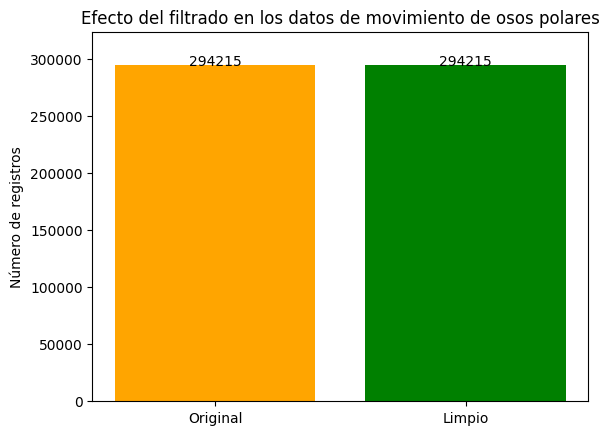

In [18]:
n_total = len(df)

# Limpieza
df_clean = df.dropna(subset=["mu_lat", "mu_lon", "timestamp"])
df_clean = df_clean[
    (df_clean["mu_lat"] > -90) & (df_clean["mu_lat"] < 90) &
    (df_clean["mu_lon"] > -180) & (df_clean["mu_lon"] < 180)
]
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")
df_clean = df_clean.dropna(subset=["timestamp"])

n_clean = len(df_clean)

# Gráfico
plt.bar(["Original", "Limpio"], [n_total, n_clean], color=["orange", "green"])
plt.ylabel("Número de registros")
plt.title("Efecto del filtrado en los datos de movimiento de osos polares")
plt.text(0, n_total + 10, f"{n_total}", ha="center")
plt.text(1, n_clean + 10, f"{n_clean}", ha="center")
plt.ylim(0, n_total * 1.1)
plt.show()


In [19]:
df.isnull().sum()

UniqueAnimalID             0
timestamp                  0
mu_lat                     0
mu_lon                     0
se_mu_x                    0
se_mu_y                    0
adj_lat                    0
adj_lon                    0
prev_lat                 393
prev_lon                 393
prev_time                  0
distance_km                0
time_diff_hr               0
velocity_kmh               0
prev_velocity              0
acceleration_kmph2         0
date                       0
daylight_hours             0
is_polar_night             0
is_midnight_sun            0
min                        0
max                        0
dias_tracking              0
TotalDistance_km           0
distance_per_day           0
AvgLatitude                0
AvgLongitude               0
Year                       0
season                     0
x_proj                     0
y_proj                     0
prev_se_x                393
prev_se_y                393
bearing                  393
prev_bearing  

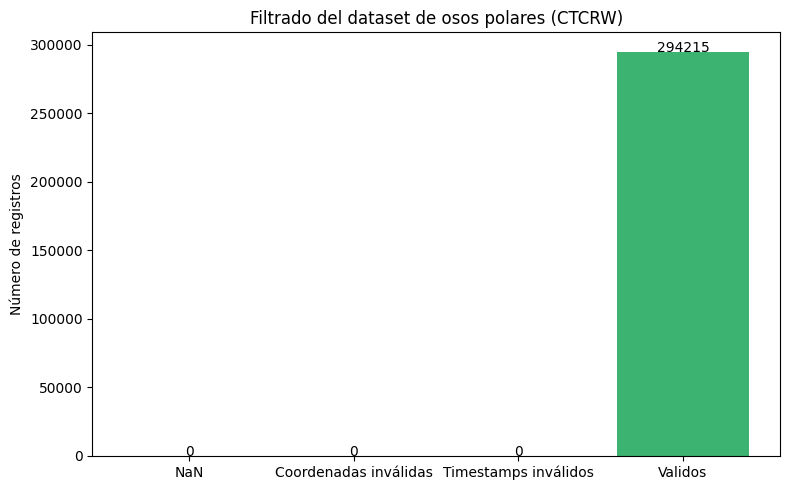

In [20]:
# Copia del DataFrame original
df = df.copy()

# Conteo inicial
n_total = len(df)
descartes = {}

# 1. NaNs en coordenadas o timestamp
mask_nan = df["mu_lat"].isna() | df["mu_lon"].isna() | df["timestamp"].isna()
descartes["NaN"] = mask_nan.sum()
df = df[~mask_nan]

# 2. Coordenadas fuera de rango
mask_coords = (
    (df["mu_lat"] < -90) | (df["mu_lat"] > 90) |
    (df["mu_lon"] < -180) | (df["mu_lon"] > 180)
)
descartes["Coordenadas inválidas"] = mask_coords.sum()
df = df[~mask_coords]

# 3. Timestamps no convertibles
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
mask_bad_time = df["timestamp"].isna()
descartes["Timestamps inválidos"] = mask_bad_time.sum()
df = df[~mask_bad_time]

# Datos limpios restantes
descartes["Validos"] = len(df)

# Gráfico
labels = list(descartes.keys())
valores = list(descartes.values())

colors = ["tomato", "orange", "orchid", "mediumseagreen"]

plt.figure(figsize=(8, 5))
plt.bar(labels, valores, color=colors)
plt.title("Filtrado del dataset de osos polares (CTCRW)")
plt.ylabel("Número de registros")
for i, val in enumerate(valores):
    plt.text(i, val + 5, str(val), ha='center')
plt.tight_layout()
plt.show()


## Calculate the average latitude and longitude for each _UniqueAnimalID_

In [10]:
avg_lat_lon = df.groupby("UniqueAnimalID")[["mu_lat", "mu_lon"]].mean()

## Calculate the _total_distance_ traveled by each bear

In [11]:
df = df.sort_values(["UniqueAnimalID", "timestamp"])

total_distance = df.groupby("UniqueAnimalID").apply(lambda group: 
    np.sum([haversine((group.iloc[i]["mu_lat"], group.iloc[i]["mu_lon"]), 
                      (group.iloc[i+1]["mu_lat"], group.iloc[i+1]["mu_lon"]), 
                      unit=Unit.KILOMETERS) 
            for i in range(len(group)-1)])
)

## Create a new dataframe with one row for each bear

In [12]:
new_df = pd.DataFrame({
    "UniqueAnimalID": avg_lat_lon.index,
    "AvgLatitude": avg_lat_lon["mu_lat"].values,
    "AvgLongitude": avg_lat_lon["mu_lon"].values,
    "TotalDistance": total_distance.values
})

In [13]:
new_df.sort_values(by='TotalDistance', ascending=False)

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance
41,56,71.995917,-143.342641,26284.098168
202,297,73.839972,-145.627765,17205.968540
28,41,72.812348,-147.170380,12993.918308
3,5,70.229730,-143.900864,12590.536328
190,280,73.686879,-157.132453,12477.245692
...,...,...,...,...
369,515,71.311370,-178.965052,148.271344
289,404,71.104967,-179.356282,116.530276
373,519,71.079553,-179.723441,51.697091
341,472,70.032390,-179.972930,40.652306


duracion del seguimiento

In [29]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
tracking_days = df.groupby("UniqueAnimalID")["timestamp"].agg(["min", "max"])
tracking_days["dias"] = (tracking_days["max"] - tracking_days["min"]).dt.days + 1


In [30]:
tracking_days.sort_values("dias", ascending=False).head()

,min,max,dias
UniqueAnimalID,,,
56,1987-07-01 18:00:00,2004-11-03 00:00:00,6335
276,1992-07-01 18:00:00,2008-11-30 18:00:00,5997
280,1999-07-01 18:00:00,2009-11-30 18:00:00,3806
351,2005-07-01 18:00:00,2015-11-30 18:00:00,3805
5,1992-07-01 18:00:00,2002-11-30 18:00:00,3805


In [31]:
tracking_days[tracking_days.index == 41]

,min,max,dias
UniqueAnimalID,,,
41,1991-07-01 18:00:00,2000-11-30 18:00:00,3441


 Calcular distancia por dia

In [32]:
df_distance = new_df[["UniqueAnimalID", "TotalDistance"]].set_index("UniqueAnimalID")
df_distance = df_distance.join(tracking_days["dias"])
df_distance["km_por_dia"] = df_distance["TotalDistance"] / df_distance["dias"]


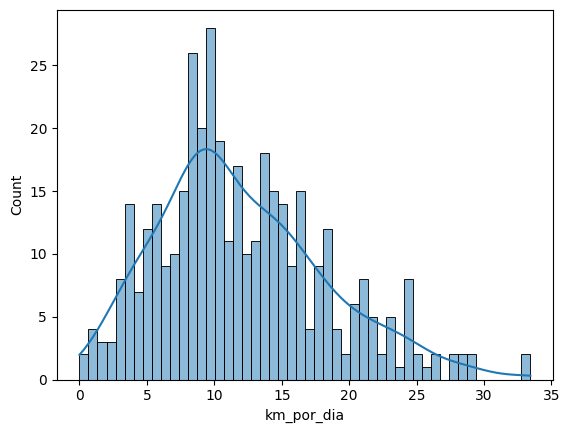

In [33]:
sns.histplot(df_distance["km_por_dia"], bins=50, kde=True);


## KMean

### Encontrar _k_ óptimo

In [34]:
X = new_df[["AvgLatitude", "AvgLongitude", "TotalDistance"]]

In [35]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=150, random_state=10).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

In [36]:
df_kmeans = pd.DataFrame(inertias, columns=['inertia'])
df_kmeans['inertia_1'] = df_kmeans['inertia'].shift(1)
df_kmeans['diff%'] = df_kmeans['inertia']/df_kmeans['inertia_1']
df_kmeans

,inertia,inertia_1,diff%
0,3.099801e+09,NaN,NaN
1,1.200245e+09,3.099801e+09,0.387201
2,6.847458e+08,1.200245e+09,0.570505
3,4.277067e+08,6.847458e+08,0.624621
4,2.681765e+08,4.277067e+08,0.627010
5,1.647826e+08,2.681765e+08,0.614456
6,1.200524e+08,1.647826e+08,0.728550
7,9.324921e+07,1.200524e+08,0.776738
8,6.718237e+07,9.324921e+07,0.720460


Text(0, 0.5, 'Inertia')

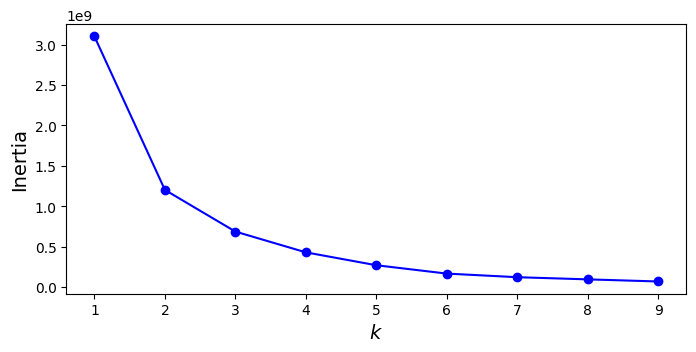

In [37]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

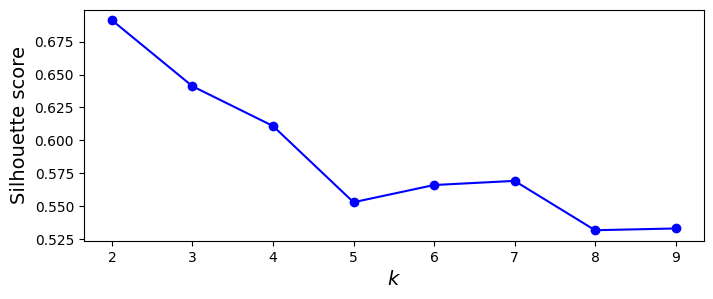

In [38]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
# plt.axis([1.8, 8.5, 0.55, 0.7])
plt.show()

In [39]:
silhouette_scores

[np.float64(0.6912815351985608),
 np.float64(0.6410505207445057),
 np.float64(0.6108422999075422),
 np.float64(0.5528586940509799),
 np.float64(0.5659468178722064),
 np.float64(0.5691025943404763),
 np.float64(0.5315789727690755),
 np.float64(0.53291746359105)]

In [40]:
# Cluster the bears using k-means
kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(new_df[["AvgLatitude", "AvgLongitude", "TotalDistance"]])
# Add the cluster labels to the dataframe
new_df["Cluster"] = clusters

In [41]:
new_df.head()

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance,Cluster
0,1,70.257515,-143.794937,1254.152678,4
1,3,72.129203,-143.771551,2688.344975,0
2,4,71.304089,-145.284885,4287.121370,2
3,5,70.229730,-143.900864,12590.536328,1
4,10,73.297852,-148.652526,5434.158260,2


In [42]:
new_df.shape

(393, 5)

## Analyze female polar bear behaviour

In [43]:
cluster_summary = new_df.groupby("Cluster").agg(
    {"UniqueAnimalID": "count",
     "AvgLatitude": "mean",
     "AvgLongitude": "mean",
     "TotalDistance": "mean"
    }
)
# Print the summary statistics for each cluster
print(cluster_summary)

         UniqueAnimalID  AvgLatitude  AvgLongitude  TotalDistance
Cluster                                                          
0                   142    72.507811   -157.599215    2767.717377
1                    27    73.019920   -151.705093   10086.460273
2                    77    72.455582   -153.176097    5411.393809
3                     1    71.995917   -143.342641   26284.098168
4                   146    71.500908   -164.039450    1167.236208


Mostrar perfiles por cluster con km/dia promedio en lugar del total

In [44]:
df_cluster_summary = new_df.merge(df_distance[["km_por_dia"]], on="UniqueAnimalID")
resumen_cluster = df_cluster_summary.groupby("Cluster").agg(
    osas=("UniqueAnimalID", "count"),
    km_dia_mean=("km_por_dia", "mean"),
    km_dia_std=("km_por_dia", "std"),
    latitud_prom=("AvgLatitude", "mean")
).reset_index()


Esto da un panorama mucho más realista y permitiría responder con confianza a preguntas como: "¿Hay grupos que se mueven más por día? ¿Existen diferencias latitudinales consistentes?"

In [45]:
resumen_cluster.sort_values(by='km_dia_mean', ascending =False)

,Cluster,osas,km_dia_mean,km_dia_std,latitud_prom
0,0,142,15.617573,5.980958,72.507811
2,2,77,10.427801,6.402637,72.455582
4,4,146,10.219965,4.983923,71.500908
1,1,27,7.735121,3.425694,73.019920
3,3,1,4.149029,NaN,71.995917


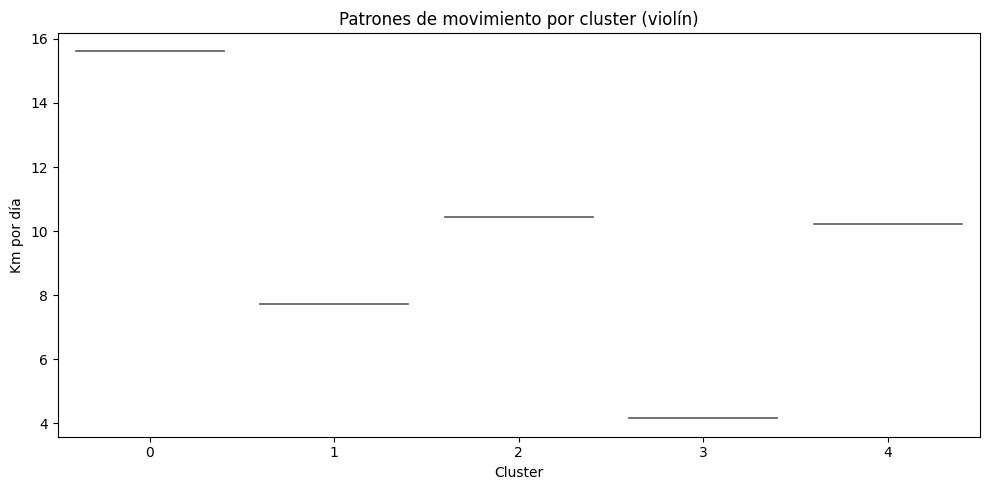

In [46]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=resumen_cluster, x="Cluster", y="km_dia_mean", palette="coolwarm", inner="quartile")
plt.title("Patrones de movimiento por cluster (violín)")
plt.xlabel("Cluster")
plt.ylabel("Km por día")
plt.tight_layout()
plt.show()


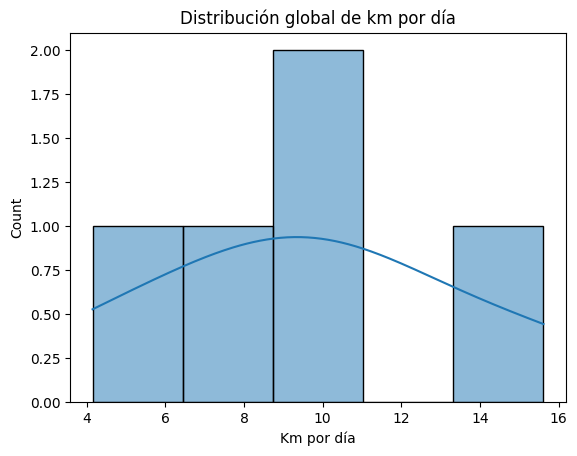

In [47]:
sns.histplot(resumen_cluster["km_dia_mean"], bins=5, kde=True)
plt.title("Distribución global de km por día")
plt.xlabel("Km por día")
plt.show()


In [48]:
new_df.head()

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance,Cluster
0,1,70.257515,-143.794937,1254.152678,4
1,3,72.129203,-143.771551,2688.344975,0
2,4,71.304089,-145.284885,4287.121370,2
3,5,70.229730,-143.900864,12590.536328,1
4,10,73.297852,-148.652526,5434.158260,2


In [49]:
# Cargar DataFrame
# new_df debe tener columnas: AvgLatitude, AvgLongitude, Cluster, UniqueAnimalID, TotalDistance
# new_df = pd.read_csv("polar_bears_summary.csv")

# Paleta de colores por clúster
cluster_colors = {
    0: "red",
    1: "blue",
    2: "green",
    3: "orange",
    4: "purple"
}

# Crea el mapa base
m = Map(center=(75, -95), zoom=3, basemap=basemaps.OpenStreetMap.Mapnik)

# Crea los marcadores
markers = []
for _, row in new_df.iterrows():
    color = cluster_colors.get(row["Cluster"], "gray")
    html = HTML()
    html.value = f"""
    <b>{row['UniqueAnimalID']}</b><br>
    Cluster: {row['Cluster']}<br>
    Distancia: {row['TotalDistance']} km
    """
    marker = Marker(location=(row["AvgLatitude"], row["AvgLongitude"]),
                    draggable=False,
                    icon_kwargs={"color": color})
    marker.popup = html
    markers.append(marker)

# Agrupa en clúster
marker_cluster = MarkerCluster(markers=markers)
m.add_layer(marker_cluster)

m


Map(center=[75, -95], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

In [50]:
from ipyleaflet import Map, CircleMarker, MarkerCluster, basemaps
from ipywidgets import HTML
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

#  `new_df` con AvgLatitude, AvgLongitude, TotalDistance, UniqueAnimalID
# Normalizar TotalDistance para colores y tamaños
distancias = new_df["TotalDistance"]
# norm = colors.Normalize(vmin=distancias.min(), vmax=distancias.max())
# colormap = cm.get_cmap("plasma")
# Normaliza la escala
norm = colors.Normalize(vmin=new_df["TotalDistance"].min(), vmax=new_df["TotalDistance"].max())
colormap_func = cm.get_cmap("viridis")  # o viridis, inferno, plasma...

# def distancia_a_color(dist):
#     rgba = colormap(norm(dist))
#     return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.7)"

def distancia_a_color(dist):
    rgba = colormap_func(norm(dist))
    r, g, b = [int(x * 255) for x in rgba[:3]]  # ignora el alpha original
    return f"rgba({r}, {g}, {b}, 0.7)"

def distancia_a_radio(dist):
    return 5 + (norm(dist) * 15)  # tamaño mínimo 5, máximo 20

# Crear el mapa
m = Map(center=(75, -95), zoom=3, basemap=basemaps.OpenStreetMap.Mapnik)

# Crear marcadores
marcadores = []
for _, row in new_df.iterrows():
    color = distancia_a_color(row["TotalDistance"])
    radio = distancia_a_radio(row["TotalDistance"])
    
    popup = HTML()
    popup.value = f"""
    <b>{'Bear Id:' + str(int(row['UniqueAnimalID']))}</b><br>
    Distancia: {row['TotalDistance']:.1f} km
    """

    marcador = CircleMarker()
    marcador.location = (row["AvgLatitude"], row["AvgLongitude"])
    marcador.radius = int(radio)
    marcador.color = color
    marcador.fill_color = color
    marcador.fill_opacity = 0.8
    marcador.popup = popup
    # marcador.draggable=True
    # marcador.zoom_control=True
    # marcador.world_copy_jump=True

    marcadores.append(marcador)


### Leyenda visual del color (_TotalDistance_)

In [51]:
# Agrupar en cluster y mostrar
import branca.colormap as bcm

# Creamos una escala del mismo rango que usamos para colorear
colormap = bcm.LinearColormap(
    colors=["blue", "lime", "yellow", "red"],
    vmin=new_df["TotalDistance"].min(),
    vmax=new_df["TotalDistance"].max(),
    caption="Distancia total recorrida (km)"
)

m.add_control(colormap)  # Esto añade la leyenda al mapa

cluster = MarkerCluster(markers=marcadores)
m.add_layer(cluster)
m


Map(center=[75, -95], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

In [38]:
new_df.head()

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance,Cluster
0,1,70.257515,-143.794937,1254.152678,3
1,3,72.129203,-143.771551,2688.344975,1
2,4,71.304089,-145.284885,4287.121370,1
3,5,70.229730,-143.900864,12590.536328,0
4,10,73.297852,-148.652526,5434.158260,2


### Cálculo de _StepsLength_ a partir de coordenadas consecutivas

In [52]:
#  Asegurar el orden temporal por individuo
df = df.sort_values(["UniqueAnimalID", "timestamp"])

from geopy.distance import geodesic

# Calculamos desplazamientos paso a paso por oso
def calcular_step_lengths(sub_df):
    '''
        Calcular _StepLength_ en kilómetros
    '''
    pasos = []
    coords = list(zip(sub_df["mu_lat"], sub_df["mu_lon"]))
    for i in range(1, len(coords)):
        d = geodesic(coords[i-1], coords[i]).kilometers
        pasos.append(d)
    # Añade un 0 al principio para que tenga el mismo número de filas
    pasos.insert(0, 0.0)
    return pasos

df["StepLength"] = df.groupby("UniqueAnimalID").apply(calcular_step_lengths).explode().astype(float).values

df.groupby("UniqueAnimalID")["StepLength"].sum()



UniqueAnimalID
1       1259.080236
3       2698.875321
4       4303.536747
5      12639.933736
10      5455.656498
           ...     
536     3791.803051
537     1336.026805
539     2310.117069
540     1258.390446
541     4863.813564
Name: StepLength, Length: 393, dtype: float64

In [53]:
new_df.head()

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance,Cluster
0,1,70.257515,-143.794937,1254.152678,4
1,3,72.129203,-143.771551,2688.344975,0
2,4,71.304089,-145.284885,4287.121370,2
3,5,70.229730,-143.900864,12590.536328,1
4,10,73.297852,-148.652526,5434.158260,2


In [54]:
df_cluster = new_df.copy()

### Slider para filtrar por año

In [55]:
df["Year"] = pd.to_datetime(df["timestamp"]).dt.year

avg_lat_lon_year = df.groupby(["UniqueAnimalID", "Year"])[["mu_lat", "mu_lon"]].mean()
total_distance_year = df.groupby(["UniqueAnimalID", "Year"])["StepLength"].sum()

new_df = pd.DataFrame({
    "UniqueAnimalID": avg_lat_lon_year.index.get_level_values(0),
    "Year": avg_lat_lon_year.index.get_level_values(1),                 # < --------------------- amplio
    "AvgLatitude": avg_lat_lon_year["mu_lat"].values,
    "AvgLongitude": avg_lat_lon_year["mu_lon"].values,
    "TotalDistance": total_distance_year.values
})


In [62]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.IntSlider(
    value=new_df["Year"].min(),
    min=new_df["Year"].min(),
    max=new_df["Year"].max(),
    step=1,
    description="Año:"
)

# Contenedor para regenerar el mapa
output_map = widgets.Output()

def actualizar_mapa(cambio):
    output_map.clear_output()
    with output_map:
        # Filtra por año
        df_filtrado = new_df[new_df["Year"] == slider.value]

        # Genera nuevos marcadores (como hicimos antes)
        marcadores = []
        for _, row in df_filtrado.iterrows():
            color = distancia_a_color(row["TotalDistance"])
            radio = distancia_a_radio(row["TotalDistance"])
            popup = HTML()
            popup.value = f"<b>{row['UniqueAnimalID']}</b><br>Distancia: {row['TotalDistance']:.1f} km"
            marcador = CircleMarker(location=(row["AvgLatitude"], row["AvgLongitude"]),
                                    radius=int(radio), color=color, fill_color=color, fill_opacity=0.8,
                                    popup=popup)
            marcadores.append(marcador)

        cluster = MarkerCluster(markers=marcadores)
        new_map = Map(center=(75, -95), zoom=3, basemap=basemaps.OpenStreetMap.Mapnik)
        new_map.add_layer(cluster)
        # new_map.add_control(colormap)
        display(new_map)

slider.observe(actualizar_mapa, names="value")
display(slider, output_map)

# Inicializa
actualizar_mapa(None)


IntSlider(value=1985, description='Año:', max=2017, min=1985)

Output()

In [63]:
df.groupby('Year')['UniqueAnimalID'].nunique().sort_values(ascending=False)

Year
2009    48
1992    40
1993    38
2008    38
1988    28
1989    28
1990    27
2004    27
2011    26
2010    25
1991    24
2005    20
2006    19
2015    18
2007    17
1987    16
2002    16
1999    16
2000    16
2013    15
2001    15
1986    13
2017    12
2014    12
2003     9
2016     9
2012     8
1994     6
1998     6
1995     3
1985     2
Name: UniqueAnimalID, dtype: int64

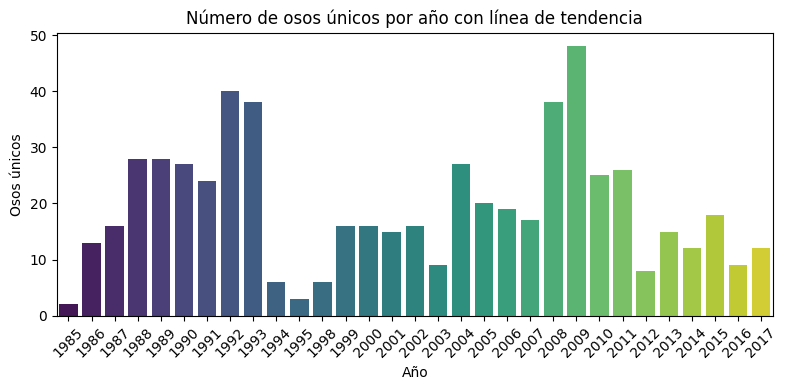

In [64]:
plt.figure(figsize=(8, 4))
sns.barplot(df.groupby('Year')['UniqueAnimalID'].nunique(), palette='viridis')
plt.xticks(rotation=30)
plt.title('Número de osos únicos por año con línea de tendencia')
plt.ylabel('Osos únicos')
plt.xlabel('Año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

### Capa dinámica de hielo marino

#### Carga y preprocesamiento de CDR de hielo marino

#### Función que genera una imagen PNG por año (como overlay)

In [65]:
from ipyleaflet import ImageOverlay
from matplotlib import cm
import xarray as xr
import numpy as np
from PIL import Image
import io
import base64
import pandas as pd

def generar_overlay_ice(year, month=9):
    # Dataset ERDDAP (NOAA/NSIDC CDR V5 mensual hemisferio norte)
    url = 'https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nh1day'

    try:
        # Abrimos el dataset remoto
        ds = xr.open_dataset(url)

        # Aseguramos formato datetime
        ds["time"] = pd.to_datetime(ds["time"].values)

        # Seleccionamos la fecha más cercana al primer día del mes y año
        fecha_objetivo = pd.Timestamp(f"{year}-{month:02d}-01")
        da = ds["cdr_seaice_conc"].sel(time=fecha_objetivo, method="nearest")

        # Datos crudos
        ice = da.values
        ice_norm = np.clip(ice / 100.0, 0, 1)

        # Aplicamos colormap
        # rgba = (cm.get_cmap("Blues_r")(ice_norm) * 255).astype(np.uint8)
        rgba = (cm.get_cmap("viridis")(ice_norm) * 255).astype(np.uint8)
        img = Image.fromarray(rgba, mode="RGBA")

        # Convertimos a base64 en memoria
        buffer = io.BytesIO()
        img.save(buffer, format="PNG")
        img_b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
        img_url = f"data:image/png;base64,{img_b64}"

        # Coordenadas del grid
        # lat_min, lat_max = float(ds["latitude"].min()), float(ds["latitude"].max())
        # lon_min, lon_max = float(ds["longitude"].min()), float(ds["longitude"].max())
        # bounds = [lat_min, lon_min, lat_max, lon_max]
        # Usamos límites fijos para el Ártico si no hay lat/lon en el dataset
        bounds = [40.0, -180.0, 90.0, 180.0]

        return ImageOverlay(url=img_url, bounds=bounds, opacity=0.4)

    except Exception as e:
        print(f"⚠️ Error al generar overlay para {year}-{month:02d}: {e}")
        return None


#### Integrarlo en el slider junto al mapa y marcadores

In [66]:
# Añadir overlay de hielo
overlay = generar_overlay_ice(slider.value)
new_map.add_layer(overlay)


NameError: name 'new_map' is not defined

In [67]:
import ipywidgets as widgets
from ipyleaflet import Map, LayersControl
from IPython.display import display

# Lista de años quinquenales disponibles
años = list(range(1985, 2025, 5))  # 1985, 1985, ..., 2020

# Crear slider
slider = widgets.IntSlider(
    value=años[0],
    options=años,
    min=min(años),
    max=max(años),
    step=5,
    description="Año:",
    style={"description_width": "60px"}
)

# Crear mapa base
m = Map(center=(75, -95), zoom=3)
m.add_control(LayersControl(position="topright"))

# Contenedor de overlay actual
overlay_actual = [None]

# Función que actualiza el mapa con el overlay correspondiente
def on_slider_change(change):
    year = change["new"]

    # Eliminar overlay anterior si existe
    if overlay_actual[0]:
        m.remove_layer(overlay_actual[0])

    # Generar nuevo overlay dinámico
    overlay_nuevo = generar_overlay_ice(year)
    if overlay_nuevo:
        m.add_layer(overlay_nuevo)
        overlay_actual[0] = overlay_nuevo
    else:
        print(f"No se pudo generar overlay para {year}")

# Vincular cambio de slider
slider.observe(on_slider_change, names="value")

from ipyleaflet import GeoJSON
import json
import requests

# Capa de países para orientación
url_geojson = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
data_geojson = requests.get(url_geojson).json()

# Añadir capa al mapa
capa_paises = GeoJSON(data=data_geojson, style={'color': 'gray', 'fillOpacity': 0})
m.add_layer(capa_paises)


# Mostrar todo
display(slider, m)
on_slider_change({"new": slider.value})  # inicializar con primer año


IntSlider(value=1985, description='Año:', max=2020, min=1985, step=5, style=SliderStyle(description_width='60p…

Map(center=[75, -95], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

### Female Polar Bear Average location

In [68]:
cluster_summary

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance
Cluster,,,,
0,142,72.507811,-157.599215,2767.717377
1,27,73.019920,-151.705093,10086.460273
2,77,72.455582,-153.176097,5411.393809
3,1,71.995917,-143.342641,26284.098168
4,146,71.500908,-164.039450,1167.236208


In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import io
import base64
import ipywidgets as widgets
from ipyleaflet import WidgetControl

def crear_leyenda_magma(min_val, max_val):
    # Crear figura horizontal
    fig, ax = plt.subplots(figsize=(4, 0.4))
    cmap = plt.get_cmap("magma")
    norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
    cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')

    ax.set_title('Cluster ID', fontsize=10)
    cb.set_ticks(range(min_val, max_val + 1))
    cb.ax.tick_params(labelsize=8)

    # Guardar como imagen base64
    buffer = io.BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight', dpi=100)
    plt.close(fig)
    img_b64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return img_b64


In [70]:
from ipyleaflet import Map, CircleMarker, LayerGroup, WidgetControl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import ipywidgets as widgets
import numpy as np

def mostrar_ositas_cluster(cluster_summary):
    m = Map(
        # center=(83, -40),
        zoom=1.3,
        scroll_wheel_zoom=True,
        dragging=True,
        zoom_control=False,
        world_copy_jump=True
    )

    # Asegurar columnas en minúsculas
    cluster_summary.columns = cluster_summary.columns.str.lower()
    cluster_summary = cluster_summary.reset_index()  # asegurar que 'cluster' sea columna

    # Elegimos un colormap más alegre 
    cmap = cm.get_cmap("magma", len(cluster_summary))
    norm = mcolors.Normalize(vmin=0, vmax=len(cluster_summary) - 1)

    # Escalado del radio en función de uniqueanimalid
    min_count = cluster_summary["uniqueanimalid"].min()
    max_count = cluster_summary["uniqueanimalid"].max()

    # Crear marcadores con colores y tamaños por cluster
    marcadores = []
    leyenda_items = []

    for i, row in cluster_summary.iterrows():
        cluster_id = row["cluster"]
        lat = row["avglatitude"]
        lon = row["avglongitude"]
        count = row["uniqueanimalid"]

        color = mcolors.to_hex(cmap(norm(i)))
        radius = np.interp(count, (min_count, max_count), (1, 8))

        marcador = CircleMarker(
            location=(lat, lon),
            radius=int(radius),
            color=color,
            fill_color=color,
            fill_opacity=0.75
        )
        marcadores.append(marcador)

        leyenda_items.append(
            f"<div style='color:{color}; font-size:14px; line-height:1.4;'><b>■</b>🐾 Cluster {cluster_id} ({count} osas)</div>"
        )

    # Añadir capa al mapa
    m.add_layer(LayerGroup(layers=marcadores))

    # Crear leyenda con HTML estilizado
    # leyenda_html = widgets.HTML(
    #     "<div style='padding: 8px; background-color: white; border:1px solid #ccc;'>"
    #     "<b>🐾 Clusters de osas polares:</b><br>" + "<br>".join(leyenda_items) + "</div>"
    # )
    # leyenda = WidgetControl(widget=leyenda_html, position="bottomright")
    # m.add_control(leyenda)

    # Rango de cluster IDs
    min_cluster = int(cluster_summary["cluster"].min())
    max_cluster = int(cluster_summary["cluster"].max())

    # Crear imagen de leyenda
    img_b64 = crear_leyenda_magma(min_cluster, max_cluster)
    leyenda_img = widgets.HTML(
        value=f"<img src='data:image/png;base64,{img_b64}' style='width:250px;'>"
    )
    leyenda_widget = WidgetControl(widget=leyenda_img, position='bottomright')
    m.add_control(leyenda_widget)


    return m


In [71]:
df_cluster.head()

,UniqueAnimalID,AvgLatitude,AvgLongitude,TotalDistance,Cluster
0,1,70.257515,-143.794937,1254.152678,4
1,3,72.129203,-143.771551,2688.344975,0
2,4,71.304089,-145.284885,4287.121370,2
3,5,70.229730,-143.900864,12590.536328,1
4,10,73.297852,-148.652526,5434.158260,2


FIONA

In [72]:
mostrar_ositas_cluster(df_cluster)

Map(center=[0.0, 0.0], controls=(AttributionControl(options=['position', 'prefix'], position='bottomright'), W…

In [ ]:
# from ipyleaflet import Map, CircleMarker, LayerGroup
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# def mostrar_ositas_cluster(df):
#     # Usamos un centro más alto y vista extendida del Ártico
#     m = Map(center=(83, -60), zoom=2.5, scroll_wheel_zoom=True)

#     # Asegurar nombres de columnas en minúsculas
#     df.columns = df.columns.str.lower()

#     # Preparar colormap viridis
#     cluster_ids = df["cluster"].unique()
#     n_clusters = len(cluster_ids)
#     cmap = cm.get_cmap("viridis", n_clusters)
#     norm = mcolors.Normalize(vmin=0, vmax=n_clusters - 1)
#     colores = {
#         cid: mcolors.to_hex(cmap(norm(i))) for i, cid in enumerate(cluster_ids)
#     }

#     marcadores = []
#     for _, row in df.iterrows():
#         color = colores[row["cluster"]]
#         marcador = CircleMarker(
#             location=(row["avglatitude"], row["avglongitude"]),
#             radius=5,
#             color=color,
#             fill_color=color,
#             fill_opacity=0.8
#         )
#         marcadores.append(marcador)

#     m.add_layer(LayerGroup(layers=marcadores))
#     return m


In [ ]:
new_df.columns

## k 2 5 vs 8

In [73]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from ipyleaflet import Map, CircleMarker, LayerGroup
from ipywidgets import VBox, Label
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def mapa_clusters_con_centroides(df, cluster_summary, k=5, cmap="magma"):
    df = df.copy()
    df.columns = df.columns.str.lower()
    cluster_summary.columns = cluster_summary.columns.str.lower()

    # Normalizar variables
    X = df[["avglatitude", "avglongitude", "totaldistance"]]
    X_scaled = StandardScaler().fit_transform(X)

    # Clustering
    modelo = KMeans(n_clusters=k, random_state=42, n_init='auto')
    df["cluster"] = modelo.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, df["cluster"])

    # Mapa base
    m = Map(center=(83, -40), zoom=1.3, scroll_wheel_zoom=True,
            dragging=True, world_copy_jump=True, zoom_control=False)

    # Colores
    cluster_ids = sorted(df["cluster"].unique())
    cmap_k = cm.get_cmap(cmap, len(cluster_ids))
    norm = mcolors.Normalize(vmin=0, vmax=len(cluster_ids) - 1)
    colores = {cid: mcolors.to_hex(cmap_k(norm(i))) for i, cid in enumerate(cluster_ids)}

    # Marcadores por osa
    marcadores = []
    for _, row in df.iterrows():
        color = colores[row["cluster"]]
        marcador = CircleMarker(
            location=(row["avglatitude"], row["avglongitude"]),
            radius=5,
            color=color,
            fill_color=color,
            fill_opacity=0.75
        )
        marcadores.append(marcador)
    m.add_layer(LayerGroup(layers=marcadores))
    
    # Centroides
    for _, row in cluster_summary.iterrows():
        marcador_centroide = CircleMarker(
            location=(row["avglatitude"], row["avglongitude"]),
            radius=9,
            color="red",
            fill_color="white",
            fill_opacity=1.0
        )
        m.add_layer(marcador_centroide)

    # Título
    titulo = f"Clustering k = {k}  (Silhouette = {sil:.2f})"
    return VBox([Label(titulo), m])

In [74]:
mapa = mapa_clusters_con_centroides(new_df, cluster_summary, k=5)
display(mapa)


In [75]:
new_df

,UniqueAnimalID,Year,AvgLatitude,AvgLongitude,TotalDistance
0,1,1986,70.257515,-143.794937,1259.080236
1,3,1985,71.688720,-144.798302,1430.155860
2,3,1986,72.559482,-142.768586,1268.719461
3,4,1988,70.631755,-139.351084,1959.171346
4,4,1990,71.981988,-151.267807,2344.365401
...,...,...,...,...,...
592,537,2008,70.222334,-141.840223,1336.026805
593,539,2009,73.359799,-140.962861,2310.117069
594,540,2009,70.219815,-144.803678,1258.390446
595,541,2006,73.930521,-154.502401,2500.893324


In [ ]:
cluster_summary

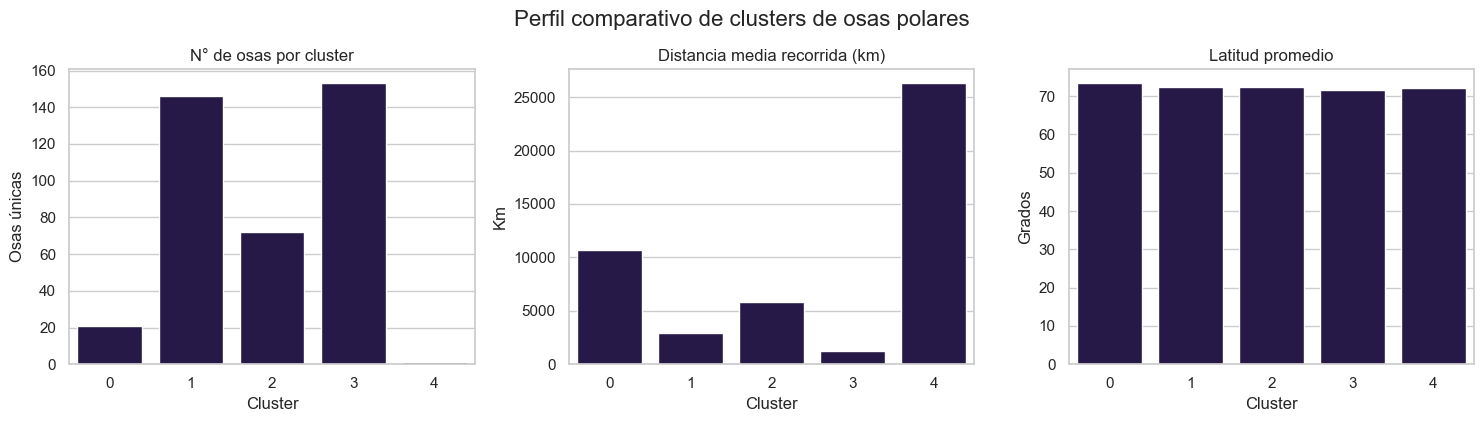

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegura nombres en minúsculas
cluster_summary_plot = cluster_summary.copy()
cluster_summary_plot.columns = cluster_summary_plot.columns.str.lower()
cluster_summary_plot = cluster_summary_plot.reset_index()

# Ordenar por TotalDistance si lo deseas
cluster_summary_plot = cluster_summary_plot.sort_values("totaldistance", ascending=False)

# Estilo de Seaborn
sns.set(style="whitegrid", palette="coolwarm")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Número de osas
sns.barplot(data=cluster_summary_plot, x="Cluster", y="uniqueanimalid", ax=axes[0])
axes[0].set_title("N° de osas por cluster")
axes[0].set_ylabel("Osas únicas")

# 2. Distancia media recorrida
sns.barplot(data=cluster_summary_plot, x="Cluster", y="totaldistance", ax=axes[1])
axes[1].set_title("Distancia media recorrida (km)")
axes[1].set_ylabel("Km")

# 3. Latitud media
sns.barplot(data=cluster_summary_plot, x="Cluster", y="avglatitude", ax=axes[2])
axes[2].set_title("Latitud promedio")
axes[2].set_ylabel("Grados")

# Ajustes finales
for ax in axes:
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.suptitle("Perfil comparativo de clusters de osas polares", fontsize=16, y=1.05)
plt.show()


In [ ]:
sns.histplot(new_df.TotalDistance)

In [ ]:
# ¿Hay alguna osa que tenga más de 10,000 km?
new_df.sort_values("TotalDistance", ascending=False).head(10)
